In [1]:
import sys
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torchvision import datasets, transforms

In [2]:
cwd = Path.cwd()
project_root = cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("done!")

done!


In [3]:
transformation = transforms.Compose([transforms.ToTensor()])

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
train_dataset = datasets.MNIST(
    root=project_root / "data",
    train=True,
    transform=transformation,
    download=True
)

In [6]:
test_dataset = datasets.MNIST(
    root=project_root / "data",
    train=False,
    transform=transformation,
    download=True
)

In [7]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [8]:
for img, label in train_dataloader:
    print(f"Label: {label}, shape: {label.shape}")
    print(f"img: {img}, shape: {img.shape}")
    break

Label: tensor([8, 8, 4, 5, 5, 2, 5, 5, 5, 9, 3, 0, 7, 9, 0, 9, 7, 7, 1, 1, 7, 5, 5, 2,
        6, 3, 8, 4, 1, 4, 5, 3, 5, 0, 4, 4, 5, 1, 5, 2, 2, 1, 4, 5, 8, 6, 1, 0,
        9, 3, 5, 3, 2, 6, 6, 6, 5, 8, 5, 0, 5, 9, 7, 1, 7, 7, 2, 3, 7, 1, 1, 8,
        4, 1, 5, 0, 9, 3, 7, 1, 8, 5, 0, 4, 2, 1, 7, 9, 9, 9, 7, 3, 2, 5, 7, 0,
        8, 0, 0, 2, 1, 9, 3, 9, 9, 4, 4, 6, 5, 3, 9, 3, 1, 8, 0, 9, 6, 8, 2, 4,
        2, 9, 3, 7, 9, 4, 6, 5]), shape: torch.Size([128])
img: tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 

### Let's build the encoder

In [9]:
class Encoder(nn.Module):
    def __init__(self, in_channels, D):
        super().__init__()
        self.conv_layer1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=4*D,
            kernel_size=4,
            stride=2,
            padding=1
        )
        self.conv_layer2 = nn.Conv2d(
            in_channels=4*D,
            out_channels=2*D,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        self.conv_layer3 = nn.Conv2d(
            in_channels=2*D,
            out_channels=D,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.relu = nn.ReLU()
        
    def forward(self, X):
        X = self.conv_layer1(X)
        X = self.relu(X)
        X = self.conv_layer2(X)
        X = self.relu(X)
        X = self.conv_layer3(X)
        return X

### Building the CodeBook

In [10]:
a = torch.randint(low=0, high=5, size=[10])
a

tensor([1, 1, 0, 0, 0, 1, 4, 0, 3, 0])

In [11]:
b = torch.randn(size=[5,4])
b

tensor([[-0.3964,  2.0081,  0.0388, -0.9017],
        [-0.6118,  0.3335,  1.1479,  0.8347],
        [ 0.0831, -0.3411, -1.5547,  0.2883],
        [ 2.0489, -0.4998,  0.1017, -1.0845],
        [ 0.7240, -1.5777,  0.4481,  1.8938]])

In [60]:
b[a]

tensor([[ 0.5354, -0.4103,  0.7632,  0.0582],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [ 0.5354, -0.4103,  0.7632,  0.0582],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [ 0.3435,  0.6824,  0.4446,  0.1129],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [-1.1940, -0.8104,  0.8754, -1.7418],
        [ 0.8960, -1.6360,  0.3892, -1.6605],
        [-1.8089, -1.2219, -0.3798, -0.2782],
        [-1.1940, -0.8104,  0.8754, -1.7418]])

In [61]:
b.argmin(dim=1)

tensor([3, 1, 3, 0, 3])

In [10]:
# class CodeBook(nn.Module):
#     def __init__(self, K, D):
#         super().__init__()
#         self.embedding = nn.Embedding(K, D)
#         self.embedding.weight.data.uniform_(-1/K, 1/K)
    
#     def forward(self, X:torch.tensor):
#         shape = X.shape
#         X = torch.reshape(X, [-1, self.embedding.weight.shape[1]])
#         distances = (X**2).sum(dim=1, keepdim=True) + ((self.embedding.weight**2).sum(dim=1, keepdim=True)).T - 2*(X @ self.embedding.weight.T)
#         min_dis_ind = distances.argmin(dim=1)
#         zq = self.embedding.weight[min_dis_ind]
#         zq_straight = X + (zq - X).detach()
#         return zq_straight.reshape(shape), zq.reshape(shape)

class CodeBook(nn.Module):
    def __init__(self, K, D):
        super().__init__()
        self.embedding = nn.Embedding(K, D)
        self.embedding.weight.data.uniform_(-1/K, 1/K)

    def forward(self, X:torch.tensor):
        B, D_c, H, W = X.shape

        X_permuted = X.permute(0, 2, 3, 1).contiguous()
        X_flattened = X_permuted.view(-1, D_c)

        distances = (X_flattened**2).sum(dim=1, keepdim=True) + ((self.embedding.weight**2).sum(dim=1, keepdim=True)).T - 2*(X_flattened @ self.embedding.weight.T)
        min_dis_ind = distances.argmin(dim=1)

        zq_flattened = self.embedding.weight[min_dis_ind]
        zq_straight_flattened = X_flattened + (zq_flattened - X_flattened).detach()

        zq_straight = zq_straight_flattened.view(B, H, W, D_c).permute(0, 3, 1, 2).contiguous()
        zq = zq_flattened.view(B, H, W, D_c).permute(0, 3, 1, 2).contiguous()

        return zq_straight, zq

### Let's Build The Decoder

In [11]:
class Decoder(nn.Module):
    def __init__(self, D):
        super().__init__()
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.inv_conv_layer1 = nn.ConvTranspose2d(
            in_channels=D,
            out_channels=2*D,
            kernel_size=3,
            padding=1,
            stride=1,
        )
        self.inv_conv_layer2 = nn.ConvTranspose2d(
            in_channels=2*D,
            out_channels=4*D,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        self.inv_conv_layer3 = nn.ConvTranspose2d(
            in_channels=4*D,
            out_channels=1,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        
    def forward(self, X):
        X = self.inv_conv_layer1(X)
        X = self.relu(X)
        X = self.inv_conv_layer2(X)
        X = self.relu(X)
        X = self.inv_conv_layer3(X)
        X = self.sigmoid(X)
        return X

## Let's combine everything and build the VQ_VAE

In [12]:
class VQ_VAE(nn.Module):
    def __init__(self, in_channels, D, K):
        super().__init__()
        self.encoder = Encoder(in_channels, D)
        self.codebook = CodeBook(K, D)
        self.decoder = Decoder(D)
        
    def forward(self, X):
        ze = self.encoder(X)
        zq_straight, zq_raw = self.codebook(ze)
        generated_img = self.decoder(zq_straight)
        return generated_img, ze, zq_raw

### Cost Function

In [13]:
def cost_fn(
    original_img,
    generated_img,
    ze,
    zq,
    beta: float = 0.25
):
    # reconstruction error
    term1 = F.binary_cross_entropy(generated_img, original_img)
    
    # codebook loss
    term2 = ((ze.detach() - zq)**2).mean()
    
    # commitment loss
    term3 = ((ze - zq.detach())**2).mean()
    
    # print(f"term 1: {term1}")
    # print(f"term 2: {term2}")
    # print(f"term 3: {term3}")
    
    loss = term1 + term2 + beta*term3
    
    return loss

### Let's Write the Training Function

In [14]:
def train(model:VQ_VAE, dataloader: DataLoader, optimizer, epochs: int):
    model.train()
    for i in range(epochs):
        total_loss = 0
        for batch in dataloader:
            img, _  = batch
            img = img.to(device)
            
            # forward pass
            generated_img, ze, zq = model.forward(img)
            # calculating loss
            loss = cost_fn(
                original_img=img,
                generated_img=generated_img,
                ze=ze,
                zq=zq
            )
            # total loss
            total_loss += loss
            # zero the gradients
            optimizer.zero_grad()
            # backward pass
            loss.backward()
            # update weights
            optimizer.step()
            
        avg_loss = total_loss/len(dataloader)
        print(f"Epoch {i+1}: Loss: {avg_loss.item():.2f}")
        
    return model

## Let's Train our VQ_VAE model

In [87]:
D = 32
K = 128
model = VQ_VAE(in_channels=1, D=D, K=K)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
trained_model = train(
    model=model,
    dataloader=train_dataloader,
    optimizer=optimizer,
    epochs=10
)

Epoch 1: Loss: 1.01
Epoch 2: Loss: 0.89
Epoch 3: Loss: 0.82
Epoch 4: Loss: 0.77
Epoch 5: Loss: 0.73
Epoch 6: Loss: 0.69
Epoch 7: Loss: 0.66
Epoch 8: Loss: 0.63
Epoch 9: Loss: 0.60
Epoch 10: Loss: 0.57


### Let's check the reconstruction

In [33]:
def visualize_reconstructions(model, dataloader, n=10):
    # Switching to eval mode
    model.eval()
    
    with torch.no_grad():
        figs, axes = plt.subplots(nrows=2, ncols=n, figsize=(12,3))
        # getting one batch
        original_imgs, _ = next(iter(dataloader))
        # inference
        generated_imgs, _, _ = model.forward(original_imgs)
        
        for i in range(n):
            axes[0, i].imshow(original_imgs[i].squeeze(), cmap='gray')
            axes[0, i].axis('off')
            
            axes[1, i].imshow(generated_imgs[i].squeeze(), cmap='gray')
            axes[1, i].axis('off')
            
        plt.show()

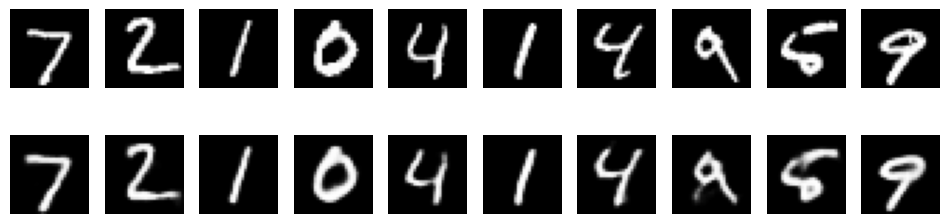

In [103]:
visualize_reconstructions(
    model=model,
    dataloader=test_dataloader,
    n=10
)

### Saving the model

In [15]:
model_weigths_path = project_root / "data" / "vqvae_mnist.pth"

In [17]:
# torch.save(model.state_dict(), str(model_weigths_path))

### Loading and Testing generation

In [16]:
D = 32
K = 128
model = VQ_VAE(in_channels=1, D=D, K=K)
model.load_state_dict(torch.load(str(model_weigths_path)))
model.eval()

VQ_VAE(
  (encoder): Encoder(
    (conv_layer1): Conv2d(1, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv_layer2): Conv2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv_layer3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
  )
  (codebook): CodeBook(
    (embedding): Embedding(128, 32)
  )
  (decoder): Decoder(
    (relu): ReLU()
    (sigmoid): Sigmoid()
    (inv_conv_layer1): ConvTranspose2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (inv_conv_layer2): ConvTranspose2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (inv_conv_layer3): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
)

### Let's visualize some stuff

Let's visulize the embedding vectors, To do that we can simply choose one vector from the embedding space and pass it through the decoder

In [19]:
np.random.randint(low=0, high=K-1, size=1)

array([28], dtype=int32)

In [20]:
random_feature = model.codebook.embedding.weight[np.random.randint(low=0, high=K-1, size=1).item()]
random_feature.shape

torch.Size([32])

In [21]:
# transforming to the expected shaped for decoder
a = torch.ones(size=[D, 7, 7])
a.shape

torch.Size([32, 7, 7])

In [ ]:
random_feature = random_feature.unsqueeze(dim=1)
random_feature = random_feature.unsqueeze(dim=1)

In [43]:
random_feature.shape

torch.Size([32, 1, 1])

In [44]:
b = random_feature * a
b

tensor([[[-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         ...,
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115],
         [-0.4115, -0.4115, -0.4115,  ..., -0.4115, -0.4115, -0.4115]],

        [[-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         ...,
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683],
         [-1.2683, -1.2683, -1.2683,  ..., -1.2683, -1.2683, -1.2683]],

        [[ 1.9940,  1.9940,  1.9940,  ...,  1.9940,  1.9940,  1.9940],
         [ 1.9940,  1.9940,  1.9940,  ...,  1

In [45]:
b = b.unsqueeze(dim=0)

In [46]:
b.shape

torch.Size([1, 32, 7, 7])

In [41]:
def visualize_codebook(model:VQ_VAE, K, D, n=64):
    if n > K:
        raise ValueError(f"n should be less than or equal {K}")
    model.eval()
    
    with torch.no_grad():
        figs, axes = plt.subplots(nrows=8, ncols=8, figsize=(8,8))
        
        for i in range(n):
            feature = model.codebook.embedding.weight[i]
            ones_vec = torch.ones(size=[D, 7, 7])
            feature = feature.unsqueeze(dim=1)
            feature = feature.unsqueeze(dim=1)
            dec_input = feature * ones_vec
            generated_feature = model.decoder.forward(dec_input)
            generated_feature = generated_feature.squeeze()
            
            row = i // 8
            col = i % 8
            axes[row, col].imshow(generated_feature, cmap='gray')
            axes[row, col].axis('off')
        
        plt.show()

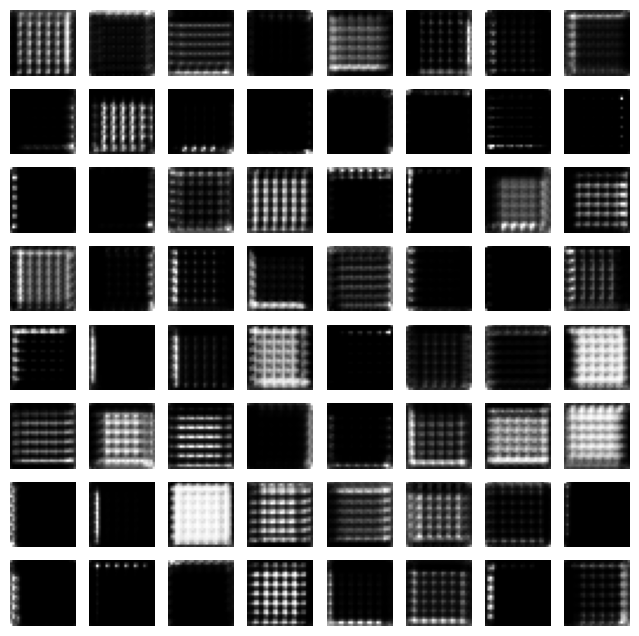

In [23]:
visualize_codebook(
    model=model,
    K=K,
    D=D,
)

## Generating New Images

In [19]:
def generate_images(model:VQ_VAE, K:int, n:int=25):
    model.eval()
    
    with torch.no_grad():
        figs, axes = plt.subplots(nrows=5, ncols=5, figsize=(8, 8))
        for i in range(n):
            # randomly sampling some features from the codebook
            random_idxs = torch.randint(low=0, high=K, size=[7, 7])
            
            # getting the features
            random_features = model.codebook.embedding.weight[random_idxs]
            
            # reshaping
            random_features = random_features.permute(2, 0, 1)
            random_features = random_features.unsqueeze(0)
            
            # generating the image
            generated_img = model.decoder.forward(random_features)
            
            row = i // 5
            col = i % 5
            axes[row, col].imshow(generated_img.squeeze(), cmap='gray')
            axes[row, col].axis('off')
            
        plt.show()

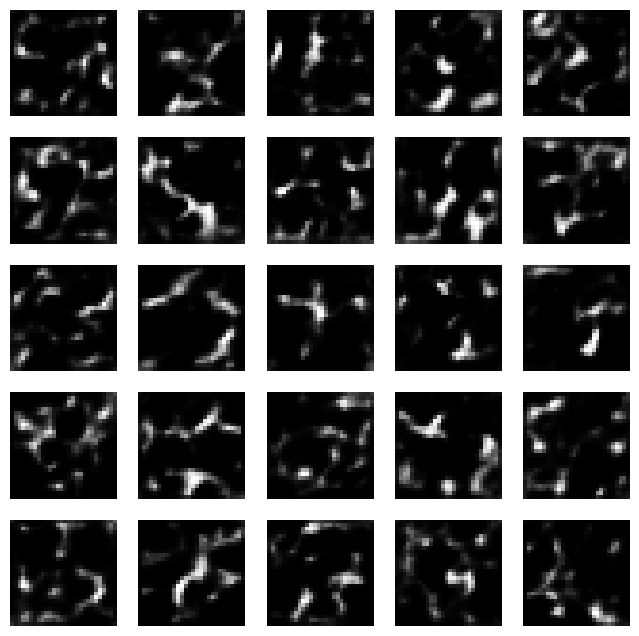

In [20]:
generate_images(
    model=model,
    K=K,
)

This does not work because we are randomly selecting some features and using then to create a image, This will up mixing the features of the images and will just create a messy image.

### Training a PixelCNN for better sampling and generation

#### Creating the training data for the PixelCNN, which is just the output of the encoder and then closest match features from the codebook. And the PixelCNN is trained on this sequence of idxes and learns how to better select the features through this sequential learning, which will lead to better sampling and better generation.

In [23]:
a = torch.ones(size=[3,4])
a

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [25]:
a.sum(dim=1, keepdim=True)

tensor([[4.],
        [4.],
        [4.]])

In [26]:
K, D

(128, 32)

In [27]:
imgs, _ = next(iter(train_dataloader))
imgs.shape

torch.Size([128, 1, 28, 28])

In [28]:
lst = []
a = torch.randint(low=1, high=50, size=[3, 4])
b = torch.randint(low=1, high=50, size=[3, 4])
lst.append(a)
lst.append(b)

In [29]:
a

tensor([[33,  6, 11,  9],
        [10, 26,  6, 49],
        [14, 38, 45,  5]])

In [30]:
b

tensor([[22, 13,  9, 40],
        [20, 18,  1, 18],
        [19, 37, 19, 25]])

In [32]:
lst, a.shape, b.shape

([tensor([[33,  6, 11,  9],
          [10, 26,  6, 49],
          [14, 38, 45,  5]]),
  tensor([[22, 13,  9, 40],
          [20, 18,  1, 18],
          [19, 37, 19, 25]])],
 torch.Size([3, 4]),
 torch.Size([3, 4]))

In [33]:
c = torch.stack(lst)
c, c.shape

(tensor([[[33,  6, 11,  9],
          [10, 26,  6, 49],
          [14, 38, 45,  5]],
 
         [[22, 13,  9, 40],
          [20, 18,  1, 18],
          [19, 37, 19, 25]]]),
 torch.Size([2, 3, 4]))

In [34]:
d = torch.cat(lst, dim=0)
d, d.shape

(tensor([[33,  6, 11,  9],
         [10, 26,  6, 49],
         [14, 38, 45,  5],
         [22, 13,  9, 40],
         [20, 18,  1, 18],
         [19, 37, 19, 25]]),
 torch.Size([6, 4]))

In [28]:
# def encode_dataset(model:VQ_VAE, dataloader:DataLoader):
#     model.eval()
#     all_indices = []
    
#     with torch.no_grad():
#         for imgs, _ in dataloader:
#             ze = model.encoder.forward(imgs) # (128, 32, 7, 7)
#             ze = torch.reshape(ze, [-1, model.codebook.embedding.weight.shape[1]]) # (128 * 7 * 7, 32) -> (6272, 32)
#             distances = (ze**2).sum(dim=1, keepdim=True) + ((model.codebook.embedding.weight**2).sum(dim=1, keepdim=True)).T - 2*(ze @ model.codebook.embedding.weight.T) # (6272, 1) + (1, 128) - (6272, 128) -> (6272, 128)
#             min_dis_ind = distances.argmin(dim=1) # (6272)
#             min_dis_ind = min_dis_ind.reshape(imgs.shape[0], 7, 7) # (128, 7, 7)
#             all_indices.append(min_dis_ind)
            
#     return torch.cat(all_indices, dim=0) # (60000, 7, 7)

def encode_dataset(model:VQ_VAE, dataloader:DataLoader):
    model.eval()
    all_indices = []

    with torch.no_grad():
        for imgs, _ in dataloader:
            imgs = imgs.to(device) 
            ze = model.encoder.forward(imgs)
            B, D_c, H, W = ze.shape

            ze_flattened = ze.permute(0, 2, 3, 1).contiguous().view(-1, D_c)

            distances = (ze_flattened**2).sum(dim=1, keepdim=True) + ((model.codebook.embedding.weight**2).sum(dim=1, keepdim=True)).T - 2*(ze_flattened @ model.codebook.embedding.weight.T)
            min_dis_ind = distances.argmin(dim=1)
            min_dis_ind = min_dis_ind.view(B, H, W)

            all_indices.append(min_dis_ind.cpu())

    return torch.cat(all_indices, dim=0)

#### Now our data to train the pixelcnn is ready now let's build the PixelCNN itself.

In [29]:
class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode="zeros", device=None, dtype=None):
        super().__init__(in_channels, out_channels, kernel_size, stride, padding, dilation, groups, bias, padding_mode, device, dtype)
        self.mask_type = mask_type
        self.register_buffer('mask', torch.ones_like(self.weight))
        self._create_mask()

    def _create_mask(self):
        k_h, k_w = self.kernel_size
        self.mask[:, :, k_h//2+1:, :] = 0

        if self.mask_type == 'A':
            self.mask[:, :, k_h//2, k_w//2:] = 0
        else:
            self.mask[:, :, k_h//2, k_w//2+1:] = 0

    def forward(self, input):
        masked_weight = self.weight * self.mask
        return F.conv2d(input, masked_weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

In [30]:
class MaskedResidualBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.relu = nn.ReLU()
        self.conv1 = MaskedConv2d('B', in_channels=hidden_dim, out_channels=hidden_dim//2, kernel_size=1)
        self.conv2 = MaskedConv2d('B', in_channels=hidden_dim//2, out_channels=hidden_dim//2, kernel_size=3, padding=1)
        self.conv3 = MaskedConv2d('B', in_channels=hidden_dim//2, out_channels=hidden_dim, kernel_size=1)

    def forward(self, x):
        residual = x
        out = self.relu(self.conv1(x))
        out = self.relu(self.conv2(out))
        out = self.conv3(out)
        return self.relu(out + residual)

In [31]:
class PixelCNN(nn.Module):
    def __init__(self, K:int, embed_dim:int, hidden_dim:int, num_res_blocks:int=5):
        super().__init__()
        self.relu = nn.ReLU()
        self.embed_layer = nn.Embedding(K, embed_dim)

        # Initial Type A convolution
        self.initial_conv = MaskedConv2d('A', in_channels=embed_dim, out_channels=hidden_dim, kernel_size=3, padding=1)

        # Stack of Residual Blocks
        self.res_blocks = nn.Sequential(
            *[MaskedResidualBlock(hidden_dim) for _ in range(num_res_blocks)]
        )

        # Final output layers (Type B)
        self.final_conv1 = MaskedConv2d('B', in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=1)
        self.final_conv2 = MaskedConv2d('B', in_channels=hidden_dim, out_channels=K, kernel_size=1)

    def forward(self, X:torch.tensor):
        X = self.embed_layer(X)
        X = X.permute(0, 3, 1, 2).contiguous()

        X = self.relu(self.initial_conv(X))
        X = self.res_blocks(X)

        X = self.relu(self.final_conv1(X))
        X = self.final_conv2(X)
        return X

In [32]:
def train_pixelcnn(pixelcnn: nn.Module, indices: torch.tensor, optimizer, scheduler, epochs):
    pixelcnn.train()
    dataset = TensorDataset(indices)
    dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            indices_batch, = batch
            indices_batch = indices_batch.to(device)

            output = pixelcnn.forward(indices_batch)
            loss = criterion(output, indices_batch.long())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Step the scheduler at the end of the epoch
        scheduler.step()

        # Get the current learning rate for logging
        current_lr = scheduler.get_last_lr()[0]

        print(f"PixelCNN Epoch {epoch+1}/{epochs}: Loss: {total_loss/len(dataloader):.4f} | LR: {current_lr:.6f}")

    return pixelcnn

In [ ]:
pixelcnn = PixelCNN(K=K, embed_dim=64, hidden_dim=256)
optimizer = torch.optim.Adam(pixelcnn.parameters(), lr=2e-4)

indices = encode_dataset(model=model, dataloader=train_dataloader)
trained_pixel_cnn = train_pixelcnn(
    pixelcnn=pixelcnn,
    indices=indices,
    optimizer=optimizer,
    epochs=10
)

Epoch 1: Loss: 3.4943
Epoch 2: Loss: 2.8202
Epoch 3: Loss: 2.6379
Epoch 4: Loss: 2.5427
Epoch 5: Loss: 2.4783
Epoch 6: Loss: 2.4297
Epoch 7: Loss: 2.3907
Epoch 8: Loss: 2.3593
Epoch 9: Loss: 2.3330
Epoch 10: Loss: 2.3109


#### Our PixelCNN has been trained

## Generating new Images

In [33]:
def generate_with_pixelcnn(pixelcnn:nn.Module, vqvae:VQ_VAE, n=25, temperature=0.8): 
    pixelcnn.eval()
    vqvae.eval()

    with torch.no_grad():
        grid = torch.zeros(n, 7, 7).long().to(device)

        for i in range(7):
            for j in range(7):
                distribution = pixelcnn.forward(grid)

                logits = distribution[:, :, i, j] / temperature

                probs = torch.softmax(logits, dim=-1)
                sampled = torch.multinomial(probs, num_samples=1)
                grid[:, i, j] = sampled.squeeze()

        sampled_features = vqvae.codebook.embedding.weight[grid]
        sampled_features = sampled_features.permute(0, 3, 1, 2).contiguous()
        generated_images = vqvae.decoder.forward(sampled_features)

        generated_images = generated_images.cpu()

        figs, axes = plt.subplots(nrows=5, ncols=5, figsize=(8,8))
        for i in range(n):
            row = i // 5
            col = i % 5
            axes[row, col].imshow(generated_images[i].squeeze(), cmap='gray')
            axes[row, col].axis('off')

        plt.show()

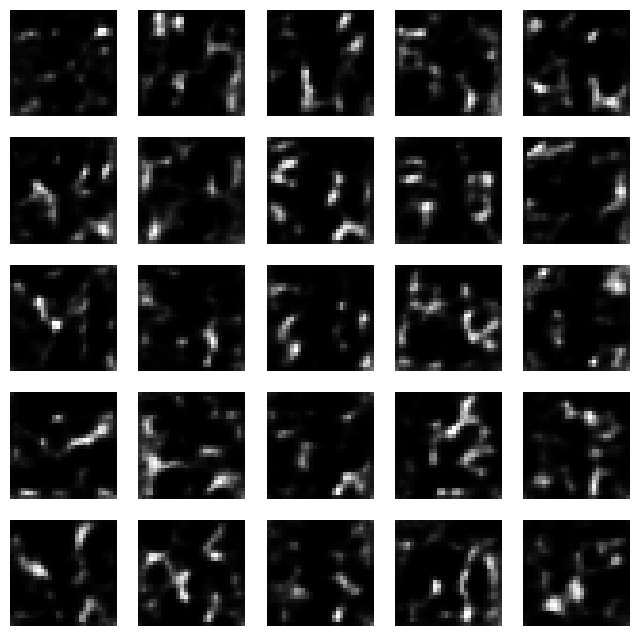

In [49]:
generate_with_pixelcnn(
    pixelcnn=trained_pixel_cnn,
    vqvae=model
)

### I think we will have to train both models a bit better and for longer

In [ ]:
D = 32
K = 64
model = VQ_VAE(in_channels=1, D=D, K=K)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
trained_vqvae_model = train(
    model=model,
    dataloader=train_dataloader,
    optimizer=optimizer,
    epochs=30
)

print(f"VQ-VAE Training Done!")

Epoch 1: Loss: 12.78
Epoch 2: Loss: 11.21
Epoch 3: Loss: 4.96
Epoch 4: Loss: 3.25
Epoch 5: Loss: 1.92
Epoch 6: Loss: 1.33
Epoch 7: Loss: 1.03
Epoch 8: Loss: 0.86
Epoch 9: Loss: 0.75
Epoch 10: Loss: 0.68
Epoch 11: Loss: 0.64
Epoch 12: Loss: 0.61
Epoch 13: Loss: 0.58
Epoch 14: Loss: 0.56
Epoch 15: Loss: 0.53
Epoch 16: Loss: 0.51
Epoch 17: Loss: 0.50
Epoch 18: Loss: 0.48
Epoch 19: Loss: 0.46
Epoch 20: Loss: 0.45
Epoch 21: Loss: 0.44
Epoch 22: Loss: 0.43
Epoch 23: Loss: 0.42
Epoch 24: Loss: 0.41
Epoch 25: Loss: 0.40
Epoch 26: Loss: 0.39
Epoch 27: Loss: 0.39
Epoch 28: Loss: 0.38
Epoch 29: Loss: 0.37
Epoch 30: Loss: 0.37
VQ-VAE Training Done!
Starting to train the PixelCNN!


NameError: name 'encode_dataset' is not defined

In [40]:
model_weigths_path = project_root / "data" / "vqvae_mnist_checkpoint_2.pth"

In [39]:
indices = encode_dataset(trained_vqvae_model, train_dataloader)

In [41]:
torch.save({
    'vqvae_state_dict': trained_vqvae_model.state_dict(),
    'indices': indices,
    'K': K,
    'D': D,
}, str(model_weigths_path))

print("Saved!")

Saved!


In [21]:
def check_codebook_usage(model, dataloader, K):
    indices = encode_dataset(model, dataloader)
    unique_codes = indices.unique()
    print(f"Codes used: {len(unique_codes)} out of {K}")

    plt.hist(indices.flatten().numpy(), bins=K)
    plt.title("Codebook Usage Distribution")
    plt.xlabel("Code index")
    plt.ylabel("Frequency")
    plt.show()

### Testing the generation of the trained vq-vae model with pixelcnn

In [22]:
vqvae_model_path = project_root / "data" / "w_vqvae_checkpoint.pth"

In [23]:
vq_vae_checkpoint = torch.load(str(vqvae_model_path), map_location=device)

In [24]:
loaded_K = vq_vae_checkpoint["K"]
loaded_D = vq_vae_checkpoint["D"]
loaded_indices = vq_vae_checkpoint['indices']

loaded_vqvae = VQ_VAE(in_channels=1, K=loaded_K, D=loaded_D).to(device)
loaded_vqvae.load_state_dict(vq_vae_checkpoint["vqvae_state_dict"])

loaded_vqvae.eval()

VQ_VAE(
  (encoder): Encoder(
    (conv_layer1): Conv2d(1, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv_layer2): Conv2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv_layer3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
  )
  (codebook): CodeBook(
    (embedding): Embedding(64, 32)
  )
  (decoder): Decoder(
    (relu): ReLU()
    (sigmoid): Sigmoid()
    (inv_conv_layer1): ConvTranspose2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (inv_conv_layer2): ConvTranspose2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (inv_conv_layer3): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
)

In [25]:
pixelcnn_checkpoint_path = project_root / "data" / "w_pixelcnn_checkpoint.pth"

In [26]:
# loading the trained pixelcnn model
pixel_cnn_checkpoint = torch.load(str(pixelcnn_checkpoint_path), map_location=device)

In [34]:
loaded_embed_dim = pixel_cnn_checkpoint["embed_dim"]
loaded_hidden_dim = pixel_cnn_checkpoint["hidden_dim"]
loaded_num_res_blocks = pixel_cnn_checkpoint["num_res_blocks"]

loaded_pixelcnn = PixelCNN(
    K=loaded_K,
    embed_dim=loaded_embed_dim,
    hidden_dim=loaded_hidden_dim,
    num_res_blocks=loaded_num_res_blocks,
)

loaded_pixelcnn.load_state_dict(pixel_cnn_checkpoint["pixelcnn_state_dict"])
loaded_pixelcnn.eval()

PixelCNN(
  (relu): ReLU()
  (embed_layer): Embedding(64, 64)
  (initial_conv): MaskedConv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (res_blocks): Sequential(
    (0): MaskedResidualBlock(
      (relu): ReLU()
      (conv1): MaskedConv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      (conv2): MaskedConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv3): MaskedConv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): MaskedResidualBlock(
      (relu): ReLU()
      (conv1): MaskedConv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      (conv2): MaskedConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv3): MaskedConv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    )
    (2): MaskedResidualBlock(
      (relu): ReLU()
      (conv1): MaskedConv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      (conv2): MaskedConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv3): MaskedConv2d(64, 1

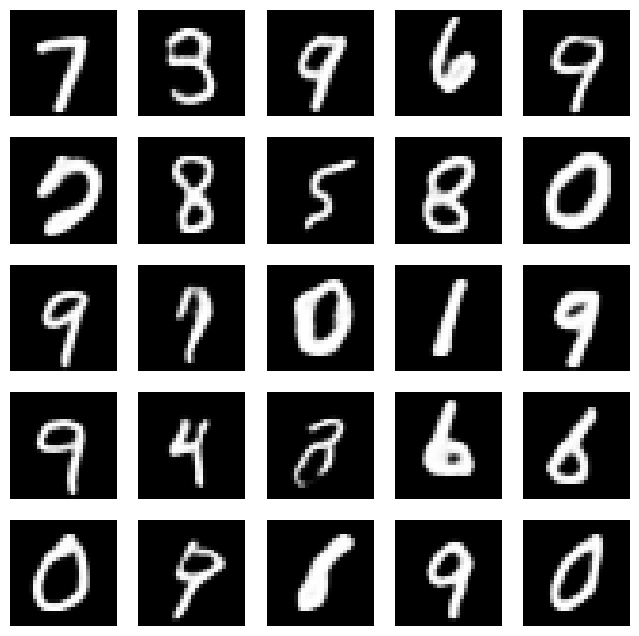

In [37]:
generate_with_pixelcnn(
    pixelcnn=loaded_pixelcnn,
    vqvae=loaded_vqvae,
    temperature=0.5
)

Codes used: 64 out of 64


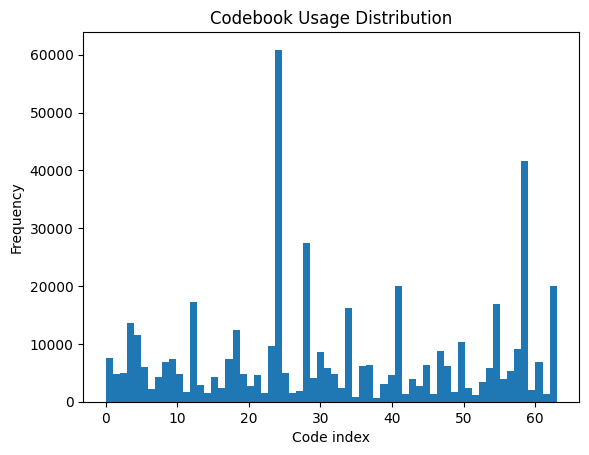

In [39]:
check_codebook_usage(
    model=loaded_vqvae,
    dataloader=test_dataloader,
    K=loaded_K
)

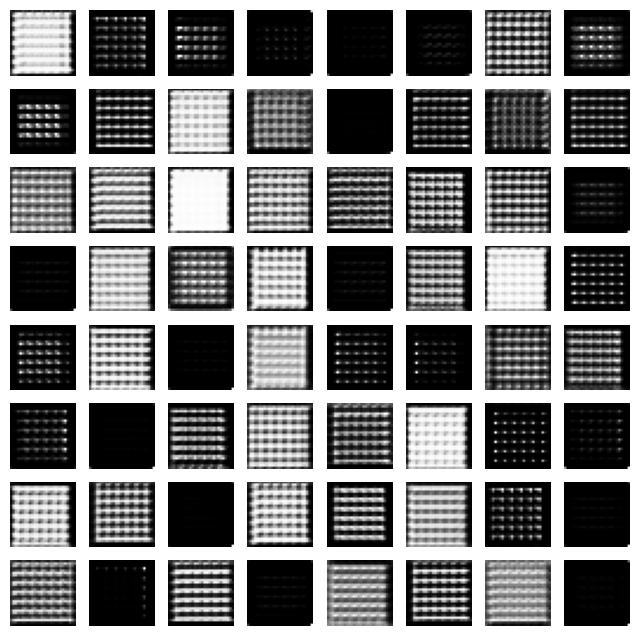

In [42]:
visualize_codebook(
    model=loaded_vqvae,
    K=loaded_K,
    D=loaded_D
)